# AgroScan — Jalon 4 (bis) : Modèle Multi-Têtes 

Un seul **backbone MobileNetV3Small** partagé → **deux têtes parallèles** :

```
MobileNetV3Small backbone
        ↓
  GlobalAveragePooling2D
        ↓
     Dropout(0.25)
       ↙         ↘
Tête espèce    Tête maladie
 Dense(13)      Dense(27)
 softmax        softmax
```

**Avantages vs hiérarchique :**
- Zéro propagation d'erreur : la tête maladie prédit **directement** les 27 classes.
- Meilleure efficacité data : un seul backbone apprend des features utiles aux deux tâches.
- Entraînement unifié : une seule boucle `fit()` au lieu de 7 modèles.
- Loss combinée `0.3 × CE_espèce + 0.7 × CE_maladie` → la tâche principale prime.

**Même stratégie :**
- Phase 1 : PlantVillage (backbone gelé)
- Phase 2 : PlantWild (25 % dégelé) — pont terrain
- Phase 3 : mixte 70 % PlantDoc (aug. renforcée) + 30 % replay PV (40 % dégelé)

## 1. Lancement

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

In [1]:
# %pip install -r ../requirements.txt kagglehub

In [2]:
import shutil
import subprocess
import os
import time
from pathlib import Path
from difflib import SequenceMatcher
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-06-01 19:29:03.833240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780342144.023476      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780342144.080099      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780342144.528889      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780342144.528925      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780342144.528928      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Configuration

In [ ]:
# Détection robuste de la racine projet
_env_root = Path(os.environ['AGROSCAN_ROOT']) if 'AGROSCAN_ROOT' in os.environ else None
IS_COLAB  = Path('/content').exists() and Path('/opt/google').exists()
_colab_root = Path('/content') if IS_COLAB else None
_cwd = Path('.').resolve()
try:
    _starting_dir = Path(get_ipython().starting_dir).resolve()
except (NameError, AttributeError):
    _starting_dir = _cwd

_candidates = list(dict.fromkeys(filter(None, [
    _env_root, _cwd, _starting_dir, *_cwd.parents, *_starting_dir.parents
])))
ROOT = next(
    (p for p in _candidates if (p / 'requirements.txt').exists()),
    _env_root or _colab_root or _cwd,
)

DATA_DIR   = ROOT / 'data'
MODEL_DIR  = ROOT / 'models'
# MODEL_DIR = Path('/kaggle/working/models')
# MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR = ROOT / 'reports'

if IS_COLAB:
    try:
        from google.colab import drive as _gdrive
        _gdrive.mount('/content/drive', force_remount=False)
        _drive_root = Path('/content/drive/MyDrive/agroscan')
        MODEL_DIR   = _drive_root / 'models'
        REPORT_DIR  = _drive_root / 'reports'
        print('Google Drive monté → artefacts dans :', _drive_root)
    except Exception as _e:
        print(f'Drive non disponible ({_e}) — sauvegarde locale /content uniquement.')

for d in [MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# Hyperparamètres du modèle multi-têtes 
MH_EPOCHS_P1, MH_LR_P1, MH_PAT_P1 = 15, 1e-3, 3
MH_EPOCHS_P2, MH_LR_P2, MH_PAT_P2, MH_UNFREEZE_P2 = 20, 1e-4, 4, 0.75
MH_EPOCHS_P3, MH_LR_P3, MH_PAT_P3, MH_UNFREEZE_P3 = 40, 3e-5, 8, 0.60

MIX_RATIO_PD, MIX_RATIO_PV = 0.70, 0.30
LABEL_SMOOTHING = 0.05

# Poids des pertes : tâche maladie (principale) > tâche espèce (auxiliaire)
LOSS_WEIGHT_SPECIES = 0.3
LOSS_WEIGHT_DISEASE = 0.7

tf.keras.utils.set_random_seed(SEED)
print('Racine projet :', ROOT)
print('Models        :', MODEL_DIR)

Racine projet : /
Models        : /kaggle/working/models


## 3. Chargement de PlantVillage

In [4]:
(pv_train_raw, pv_val_raw, pv_test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names     = info.features['label'].names
num_classes_pv  = len(class_names)
pv_label_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f'PlantVillage : {num_classes_pv} classes')
print(f'Ex. : {class_names[:5]}')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /data/tfds/plant_village/incomplete.HBRPOI_1.0.2/plant_village-train.tfrecord*...:   0%|          | …

Dataset plant_village downloaded and prepared to /data/tfds/plant_village/1.0.2. Subsequent calls will reuse this data.


I0000 00:00:1780342305.145315      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780342305.148024      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


PlantVillage : 38 classes
Ex. : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## 4. Configuration PlantDoc + mapping

In [5]:
PLANTDOC_DIR       = DATA_DIR / 'plantdoc'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                       'Apple___Apple_scab',
    'Apple leaf':                            'Apple___healthy',
    'Apple rust leaf':                       'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                      'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                        'Blueberry___healthy',
    'Cherry leaf':                           'Cherry___healthy',
    'Corn Gray leaf spot':                   'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                      'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                        'Corn___Common_rust',
    'Peach leaf':                            'Peach___healthy',
    'Potato leaf early blight':              'Potato___Early_blight',
    'Potato leaf late blight':               'Potato___Late_blight',
    'Raspberry leaf':                        'Raspberry___healthy',
    'Soyabean leaf':                         'Soybean___healthy',
    'Squash Powdery mildew leaf':            'Squash___Powdery_mildew',
    'Strawberry leaf':                       'Strawberry___healthy',
    'Tomato Early blight leaf':              'Tomato___Early_blight',
    'Tomato Septoria leaf spot':             'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                           'Tomato___healthy',
    'Tomato leaf bacterial spot':            'Tomato___Bacterial_spot',
    'Tomato leaf late blight':               'Tomato___Late_blight',
    'Tomato leaf mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':              'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                      'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':  'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                            'Grape___healthy',
    'grape leaf black rot':                  'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('Téléchargement de PlantDoc...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp = DATA_DIR / '_pd_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git', str(tmp)],
        check=True,
    )
    for split in ('train', 'test'):
        src, dst = tmp / split, PLANTDOC_DIR / split
        if src.exists() and not dst.exists():
            shutil.copytree(src, dst)
    shutil.rmtree(tmp)
    print('PlantDoc téléchargé.')

plantdoc_classes = sorted(p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir())
valid_pd_mapping = {
    k: v for k, v in plantdoc_to_plantvillage.items()
    if k in plantdoc_classes and v in class_names
}
print(f'PlantDoc test : {len(plantdoc_classes)} classes | {len(valid_pd_mapping)} évaluables')

Téléchargement de PlantDoc...


Cloning into '/data/_pd_clone'...
Updating files: 100% (2581/2581), done.


PlantDoc téléchargé.
PlantDoc test : 27 classes | 27 évaluables


## 5. Univers restreint aux 27 classes PlantDoc

In [6]:
allowed_pv_names = sorted(set(valid_pd_mapping.values()))
allowed_pv_idx   = [pv_label_to_idx[n] for n in allowed_pv_names]
allowed_set      = set(allowed_pv_idx)
n_allowed        = len(allowed_pv_idx)

global_to_pos = {g: pos for pos, g in enumerate(allowed_pv_idx)}
pos_to_name   = {pos: class_names[g] for g, pos in global_to_pos.items()}

allowed_idx_tensor = tf.constant(allowed_pv_idx, dtype=tf.int64)

print(f'Univers restreint : {n_allowed} classes PlantDoc')
for pos in range(n_allowed):
    print(f'  [{pos:2d}] {pos_to_name[pos]}')

Univers restreint : 27 classes PlantDoc
  [ 0] Apple___Apple_scab
  [ 1] Apple___Cedar_apple_rust
  [ 2] Apple___healthy
  [ 3] Blueberry___healthy
  [ 4] Cherry___healthy
  [ 5] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [ 6] Corn___Common_rust
  [ 7] Corn___Northern_Leaf_Blight
  [ 8] Grape___Black_rot
  [ 9] Grape___healthy
  [10] Peach___healthy
  [11] Pepper,_bell___Bacterial_spot
  [12] Pepper,_bell___healthy
  [13] Potato___Early_blight
  [14] Potato___Late_blight
  [15] Raspberry___healthy
  [16] Soybean___healthy
  [17] Squash___Powdery_mildew
  [18] Strawberry___healthy
  [19] Tomato___Bacterial_spot
  [20] Tomato___Early_blight
  [21] Tomato___Late_blight
  [22] Tomato___Leaf_Mold
  [23] Tomato___Septoria_leaf_spot
  [24] Tomato___Tomato_Yellow_Leaf_Curl_Virus
  [25] Tomato___Tomato_mosaic_virus
  [26] Tomato___healthy


## 6. Taxonomie espèce / maladie

In [7]:
def species_of(pv_name):
    return pv_name.split('___')[0]

species_names  = sorted(set(species_of(n) for n in allowed_pv_names))
species_to_idx = {s: i for i, s in enumerate(species_names)}
n_species      = len(species_names)

def clean_name(s):
    out = s
    for ch in (',', ' ', '(', ')', '/', '\\'):
        out = out.replace(ch, '_')
    while '__' in out:
        out = out.replace('__', '_')
    return out.strip('_')

species_display = [clean_name(s) for s in species_names]

# Lookup tensor : pv_global_idx (0..37) → species_idx (0..n_species-1)
pv_to_species_arr = np.full(num_classes_pv, -1, dtype=np.int64)
for g in allowed_pv_idx:
    pv_to_species_arr[g] = species_to_idx[species_of(class_names[g])]
pv_to_species_tensor = tf.constant(pv_to_species_arr, dtype=tf.int64)

# Lookup tensor : pv_global_idx (0..37) → position dans l'univers (0..26)
pv_to_pos_arr = np.full(num_classes_pv, -1, dtype=np.int64)
for g, pos in global_to_pos.items():
    pv_to_pos_arr[g] = pos
pv_to_pos_tensor = tf.constant(pv_to_pos_arr, dtype=tf.int64)

# Espèces → liste de positions dans l'univers (pour masquage optionnel en inférence)
species_disease_global = {s: [] for s in range(n_species)}
for g in allowed_pv_idx:
    species_disease_global[species_to_idx[species_of(class_names[g])]].append(g)
for s in species_disease_global:
    species_disease_global[s] = sorted(species_disease_global[s])

multi_species = [s for s in range(n_species) if len(species_disease_global[s]) > 1]
mono_species  = [s for s in range(n_species) if len(species_disease_global[s]) == 1]

print(f'{n_species} espèces, {n_allowed} classes maladie (univers PlantDoc)')
print(f'{len(multi_species)} espèces multi-maladies, {len(mono_species)} mono-classe')

13 espèces, 27 classes maladie (univers PlantDoc)
6 espèces multi-maladies, 7 mono-classe


## 7. Chargement et mapping de PlantWild

In [8]:
PLANTWILD_DIR = DATA_DIR / 'plantwild'

if not PLANTWILD_DIR.exists():
    print('PlantWild non trouvé. Tentative de téléchargement via kagglehub...')
    try:
        import kagglehub
        path = kagglehub.dataset_download('thuanai1/plantwild')
        PLANTWILD_DIR = Path(path)
        print('Téléchargé dans :', PLANTWILD_DIR)
    except Exception as e:
        raise FileNotFoundError(
            f'PlantWild non trouvé ({e}).\n'
            'Télécharger sur https://www.kaggle.com/datasets/thuanai1/plantwild\n'
            'et extraire dans data/plantwild/ (train/ val/)'
        ) from e

for candidate in [PLANTWILD_DIR, PLANTWILD_DIR / 'plantwild', *list(PLANTWILD_DIR.iterdir())]:
    if (candidate / 'train').exists():
        PLANTWILD_TRAIN_DIR = candidate / 'train'
        PLANTWILD_VAL_DIR   = candidate / 'val'
        break
else:
    raise FileNotFoundError(f'Structure train/ introuvable dans {PLANTWILD_DIR}')

print('PlantWild train :', PLANTWILD_TRAIN_DIR)

PlantWild non trouvé. Tentative de téléchargement via kagglehub...
Téléchargé dans : /kaggle/input/datasets/thuanai1/plantwild
PlantWild train : /kaggle/input/datasets/thuanai1/plantwild/train


In [9]:
plantwild_to_plantvillage = {
    'apple scab':                    'Apple___Apple_scab',
    'apple black rot':               'Apple___Black_rot',
    'apple rust':                    'Apple___Cedar_apple_rust',
    'apple leaf':                    'Apple___healthy',
    'blueberry leaf':                'Blueberry___healthy',
    'cherry leaf':                   'Cherry___healthy',
    'cherry powdery mildew':         'Cherry___Powdery_mildew',
    'corn gray leaf spot':           'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn leaf blight':              'Corn___Northern_Leaf_Blight',
    'corn rust':                     'Corn___Common_rust',
    'corn leaf':                     'Corn___healthy',
    'grape black rot':               'Grape___Black_rot',
    'grape esca':                    'Grape___Esca_(Black_Measles)',
    'grape leaf blight':             'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'grape leaf':                    'Grape___healthy',
    'orange citrus greening':        'Orange___Haunglongbing_(Citrus_greening)',
    'orange haunglongbing':          'Orange___Haunglongbing_(Citrus_greening)',
    'peach bacterial spot':          'Peach___Bacterial_spot',
    'peach leaf':                    'Peach___healthy',
    'bell pepper leaf spot':         'Pepper,_bell___Bacterial_spot',
    'bell pepper leaf':              'Pepper,_bell___healthy',
    'potato early blight':           'Potato___Early_blight',
    'potato late blight':            'Potato___Late_blight',
    'potato leaf':                   'Potato___healthy',
    'raspberry leaf':                'Raspberry___healthy',
    'soybean leaf':                  'Soybean___healthy',
    'squash powdery mildew':         'Squash___Powdery_mildew',
    'strawberry leaf scorch':        'Strawberry___Leaf_scorch',
    'strawberry leaf':               'Strawberry___healthy',
    'tomato bacterial spot':         'Tomato___Bacterial_spot',
    'tomato early blight':           'Tomato___Early_blight',
    'tomato late blight':            'Tomato___Late_blight',
    'tomato leaf mold':              'Tomato___Leaf_Mold',
    'tomato septoria leaf spot':     'Tomato___Septoria_leaf_spot',
    'tomato spider mites':           'Tomato___Spider_mites Two-spotted_spider_mite',
    'tomato target spot':            'Tomato___Target_Spot',
    'tomato yellow leaf curl virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mosaic virus':           'Tomato___Tomato_mosaic_virus',
    'tomato leaf':                   'Tomato___healthy',
}
print(f'Mapping PlantWild → PV : {len(plantwild_to_plantvillage)} entrées')

Mapping PlantWild → PV : 39 entrées


In [10]:
def fuzzy_match(query, candidates, threshold=0.7):
    best, best_score = None, 0.0
    for c in candidates:
        score = SequenceMatcher(None, query, c).ratio()
        if score > best_score:
            best, best_score = c, score
    return best if best_score >= threshold else None


def load_plantwild_split(split_dir):
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths, labels = [], []
    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls_name = cls_dir.name.lower()
        pv_cls = plantwild_to_plantvillage.get(cls_name)
        if pv_cls is None:
            match = fuzzy_match(cls_name, list(plantwild_to_plantvillage.keys()))
            if match:
                pv_cls = plantwild_to_plantvillage[match]
        if pv_cls is None or pv_cls not in pv_label_to_idx:
            continue
        pv_idx = pv_label_to_idx[pv_cls]
        if pv_idx not in allowed_set:
            continue
        for p in cls_dir.iterdir():
            if p.is_file() and p.suffix.lower() in image_exts:
                paths.append(str(p))
                labels.append(pv_idx)
    return paths, labels


pw_train_paths, pw_train_labels = load_plantwild_split(PLANTWILD_TRAIN_DIR)
if PLANTWILD_VAL_DIR.exists():
    pw_val_paths, pw_val_labels = load_plantwild_split(PLANTWILD_VAL_DIR)
else:
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(pw_train_paths))
    pw_train_paths  = [pw_train_paths[i]  for i in perm]
    pw_train_labels = [pw_train_labels[i] for i in perm]
    n_val = int(0.2 * len(pw_train_paths))
    pw_val_paths,   pw_val_labels   = pw_train_paths[:n_val],  pw_train_labels[:n_val]
    pw_train_paths, pw_train_labels = pw_train_paths[n_val:],  pw_train_labels[n_val:]

print(f'PlantWild (univers 27) train : {len(pw_train_paths):,} | val : {len(pw_val_labels):,}')
print(f'Classes couvertes : {len(set(pw_train_labels))} / {n_allowed}')

PlantWild (univers 27) train : 7,074 | val : 994
Classes couvertes : 27 / 27


## 8. Collecte des images PlantDoc train (univers 27)

In [11]:
pd_train_paths, pd_train_glob = [], []
for pd_cls, pv_cls in valid_pd_mapping.items():
    cls_dir = PLANTDOC_TRAIN_DIR / pd_cls
    g = pv_label_to_idx.get(pv_cls)
    if g is None or g not in allowed_set or not cls_dir.exists():
        continue
    for p in sorted(cls_dir.iterdir()):
        if p.is_file():
            pd_train_paths.append(str(p))
            pd_train_glob.append(g)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(pd_train_paths))
pd_train_paths = [pd_train_paths[i] for i in perm]
pd_train_glob  = [pd_train_glob[i]  for i in perm]

n_val_pd = int(0.2 * len(pd_train_paths))
pd_val_paths,   pd_val_glob   = pd_train_paths[:n_val_pd], pd_train_glob[:n_val_pd]
pd_train_paths, pd_train_glob = pd_train_paths[n_val_pd:], pd_train_glob[n_val_pd:]

print(f'PlantDoc train : {len(pd_train_paths):,} | val : {len(pd_val_paths):,}')
print(f'Classes couvertes : {len(set(pd_train_glob))} / {n_allowed}')

PlantDoc train : 1,872 | val : 468
Classes couvertes : 27 / 27


## 9. Augmentation et fonctions de chargement

Toutes les fonctions de chargement retournent désormais `(image, {'species': y_sp, 'disease': y_pos})`
pour alimenter les deux têtes simultanément.

In [12]:
def apply_random_blur(image):
    do_blur = tf.cast(tf.random.uniform([]) < 0.4, tf.float32)
    img_4d  = tf.expand_dims(image, 0)
    blurred = tf.nn.avg_pool2d(img_4d, ksize=3, strides=1, padding='SAME')
    blurred = tf.squeeze(blurred, 0)
    return do_blur * blurred + (1.0 - do_blur) * image


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.10), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10'),
], name='data_augmentation_standard')

data_augmentation_heavy = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.35, seed=SEED),
    tf.keras.layers.RandomZoom((-0.50, 0.15), seed=SEED),
    tf.keras.layers.RandomContrast(0.6, seed=SEED),
    tf.keras.layers.RandomBrightness(0.4, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=18.0),
        name='gaussian_noise_18'),
    tf.keras.layers.Lambda(apply_random_blur, name='random_blur'),
], name='data_augmentation_heavy')


def _dual_labels(global_label):
    """Convertit un label PV global → {'species': idx_espèce, 'disease': pos_univers}."""
    sp  = tf.gather(pv_to_species_tensor, tf.cast(global_label, tf.int64))
    pos = tf.gather(pv_to_pos_tensor,     tf.cast(global_label, tf.int64))
    return {'species': sp, 'disease': pos}


def preprocess_pv_dual(image, label, augment=False):
    img = tf.image.resize(image, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, _dual_labels(label)


def load_dual_image(path, global_label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, _dual_labels(global_label)


def load_dual_image_heavy(path, global_label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img = data_augmentation_heavy(img, training=True)
    return img, _dual_labels(global_label)


print('Augmentation et fonctions de chargement prêtes.')

Augmentation et fonctions de chargement prêtes.


## 10. Architecture — modèle multi-têtes

Un seul backbone MobileNetV3Small partagé, deux têtes de classification indépendantes.
La tête `disease` est la sortie principale (pondérée 0.7) ; la tête `species` est
une tâche auxiliaire (pondérée 0.3) qui aide le backbone à apprendre des features
sémantiques robustes.

In [13]:
class LabelSmoothingLoss(tf.keras.losses.Loss):
    """Sparse CE + label smoothing (SparseCCE ne supporte pas le smoothing natif)."""
    def __init__(self, num_classes, smoothing=0.05, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.smoothing   = smoothing

    def call(self, y_true, y_pred):
        y_true_flat = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_one_hot   = tf.one_hot(y_true_flat, self.num_classes)
        return tf.keras.losses.categorical_crossentropy(
            y_one_hot, y_pred, label_smoothing=self.smoothing)

    def get_config(self):
        c = super().get_config()
        c.update({'num_classes': self.num_classes, 'smoothing': self.smoothing})
        return c


def build_multihead_model(n_species, n_disease, name='agroscan_two_head'):
    """
    Construit le modèle multi-têtes.
    Retourne (model, backbone) pour pouvoir gérer le dégel progressif.
    """
    backbone = tf.keras.applications.MobileNetV3Small(
        input_shape=IMG_SIZE + (3,),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True,
    )
    backbone.trainable = False

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,), name='image')
    x = backbone(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name='gap')(x)
    x = tf.keras.layers.Dropout(0.25, name='shared_dropout')(x)

    # Tête espèce (tâche auxiliaire)
    species_out = tf.keras.layers.Dense(
        n_species, activation='softmax', name='species')(x)

    # Tête maladie (tâche principale)
    disease_out = tf.keras.layers.Dense(
        n_disease, activation='softmax', name='disease')(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs={'species': species_out, 'disease': disease_out},
        name=name,
    )
    return model, backbone


def set_unfreeze(backbone, frozen_ratio):
    """Gèle les `frozen_ratio` premières couches, dégèle le reste."""
    n_total  = len(backbone.layers)
    n_frozen = int(n_total * frozen_ratio)
    for layer in backbone.layers[:n_frozen]:
        layer.trainable = False
    for layer in backbone.layers[n_frozen:]:
        layer.trainable = True
    return n_frozen, n_total


print('Fabrique de modèle multi-têtes prête.')

Fabrique de modèle multi-têtes prête.


## 11. Construction des datasets (double label)

Chaque exemple produit `(image, {'species': y_sp, 'disease': y_pos})`.

In [ ]:
def in_allowed(image, label):
    return tf.reduce_any(tf.equal(tf.cast(label, tf.int64), allowed_idx_tensor))

# Phase 1 — PlantVillage 
p1_train = (
    pv_train_raw
    .filter(in_allowed)
    .shuffle(4096, seed=SEED)
    .map(lambda x, y: preprocess_pv_dual(x, y, True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
p1_val = (
    pv_val_raw
    .filter(in_allowed)
    .map(lambda x, y: preprocess_pv_dual(x, y, False), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

# Phase 2 — PlantWild 
pw_train_arr = np.array(pw_train_labels, dtype=np.int64)
pw_val_arr   = np.array(pw_val_labels,   dtype=np.int64)

p2_train = (
    tf.data.Dataset.from_tensor_slices((pw_train_paths, pw_train_arr))
    .shuffle(4096, seed=SEED)
    .map(lambda p, l: load_dual_image(p, l, True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
p2_val = (
    tf.data.Dataset.from_tensor_slices((pw_val_paths, pw_val_arr))
    .map(load_dual_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

# Phase 3 — Mixte PlantDoc (aug. renforcée) + replay PV 
pd_train_arr = np.array(pd_train_glob, dtype=np.int64)
pd_val_arr   = np.array(pd_val_glob,   dtype=np.int64)

pd_unb = (
    tf.data.Dataset.from_tensor_slices((pd_train_paths, pd_train_arr))
    .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    .map(load_dual_image_heavy, num_parallel_calls=AUTOTUNE)
    .repeat()
)
pv_unb = (
    pv_train_raw
    .filter(in_allowed)
    .shuffle(8192, seed=SEED, reshuffle_each_iteration=True)
    .map(lambda x, y: preprocess_pv_dual(x, y, True), num_parallel_calls=AUTOTUNE)
    .repeat()
)
p3_train = (
    tf.data.Dataset.sample_from_datasets(
        [pd_unb, pv_unb], weights=[MIX_RATIO_PD, MIX_RATIO_PV], seed=SEED)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
p3_val = (
    tf.data.Dataset.from_tensor_slices((pd_val_paths, pd_val_arr))
    .map(load_dual_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE).prefetch(AUTOTUNE)
)

steps_p3 = max(1, len(pd_train_paths) // BATCH_SIZE)
print(f'Datasets prêts. steps_per_epoch P3 = {steps_p3}')

Datasets prêts. steps_per_epoch P3 = 58


## 12. Instanciation du modèle

In [15]:
model, backbone = build_multihead_model(n_species, n_allowed)

model.compile(
    optimizer=tf.keras.optimizers.Adam(MH_LR_P1),
    loss={
        'species': 'sparse_categorical_crossentropy',
        'disease': 'sparse_categorical_crossentropy',
    },
    loss_weights={
        'species': LOSS_WEIGHT_SPECIES,
        'disease': LOSS_WEIGHT_DISEASE,
    },
    metrics={
        'species': 'accuracy',
        'disease': 'accuracy',
    },
)

print(f'Modèle multi-têtes : {n_species} espèces | {n_allowed} maladies')
print(f'Paramètres total   : {model.count_params():,}')
model.summary(line_length=90)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modèle multi-têtes : 13 espèces | 27 maladies
Paramètres total   : 962,200


Model: "agroscan_two_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)       │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ MobileNetV3Small         │ (None, 7, 7, 576)    │      939,120 │ image[0][0]           │
│ (Functional)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ gap                      │ (None, 576)          │            0 │ MobileNetV3Small[0][… │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ shared_dropout (Dropout) │ (None, 576)          │            0 │ gap[0][0]             │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ disease (Dense)          │ (None, 27)           │       15,579 │ shared_dropout[0][0]  │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ species (Dense)          │ (None, 13)           │        7,501 │ shared_dropout[0][0]  │
└──────────────────────────┴──────────────────────┴──────────────┴───────────────────────┘

 Total params: 962,200 (3.67 MB)

 Trainable params: 23,080 (90.16 KB)

 Non-trainable params: 939,120 (3.58 MB)

## 13. Phase 1 — PlantVillage (backbone gelé)

On entraîne les deux têtes de classification pendant que le backbone reste gelé.
Objectif : convergence rapide sur données studio avant adaptation terrain.

In [16]:
cb_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'two_head_p1.keras'),
        monitor='val_disease_accuracy', mode='max', save_best_only=True, verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_disease_accuracy', mode='max', patience=MH_PAT_P1,
        restore_best_weights=True),
]

t0 = time.time()
h_p1 = model.fit(
    p1_train, validation_data=p1_val,
    epochs=MH_EPOCHS_P1, callbacks=cb_p1,
)
print(f'Phase 1 terminée en {time.time()-t0:.0f}s')

Epoch 1/15


I0000 00:00:1780342367.368373     361 service.cc:152] XLA service 0x7d64040798d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780342367.368409     361 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780342367.368414     361 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780342368.930653     361 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780342376.557011     361 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    805/Unknown 183s 208ms/step - disease_accuracy: 0.5824 - disease_loss: 1.5584 - loss: 1.3627 - species_accuracy: 0.7357 - species_loss: 0.9060

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


805/805 ━━━━━━━━━━━━━━━━━━━━ 198s 225ms/step - disease_accuracy: 0.7353 - disease_loss: 0.9699 - loss: 0.8430 - species_accuracy: 0.8411 - species_loss: 0.5467 - val_disease_accuracy: 0.8763 - val_disease_loss: 0.4651 - val_loss: 0.3930 - val_species_accuracy: 0.9472 - val_species_loss: 0.2229
Epoch 2/15
805/805 ━━━━━━━━━━━━━━━━━━━━ 164s 202ms/step - disease_accuracy: 0.8791 - disease_loss: 0.4218 - loss: 0.3627 - species_accuracy: 0.9350 - species_loss: 0.2247 - val_disease_accuracy: 0.9113 - val_disease_loss: 0.3206 - val_loss: 0.2751 - val_species_accuracy: 0.9544 - val_species_loss: 0.1679
Epoch 3/15
805/805 ━━━━━━━━━━━━━━━━━━━━ 164s 202ms/step - disease_accuracy: 0.8955 - disease_loss: 0.3441 - loss: 0.2963 - species_accuracy: 0.9438 - species_loss: 0.1848 - val_disease_accuracy: 0.9201 - val_disease_loss: 0.2725 - val_loss: 0.2344 - val_species_accuracy: 0.9582 - val_species_loss: 0.1445
Epoch 4/15
805/805 ━━━━━━━━━━━━━━━━━━━━ 165s 203ms/step - disease_accuracy: 0.9082 - disease_

## 14. Phase 2 — PlantWild (25 % backbone dégelé)

Adaptation au « terrain » via PlantWild (photos réelles, variabilité conditions).

In [17]:
nf, nt = set_unfreeze(backbone, MH_UNFREEZE_P2)
print(f'Phase 2 backbone : {nf}/{nt} couches gelées')

model.compile(
    optimizer=tf.keras.optimizers.Adam(MH_LR_P2),
    loss={
        'species': 'sparse_categorical_crossentropy',
        'disease': 'sparse_categorical_crossentropy',
    },
    loss_weights={
        'species': LOSS_WEIGHT_SPECIES,
        'disease': LOSS_WEIGHT_DISEASE,
    },
    metrics={
        'species': 'accuracy',
        'disease': 'accuracy',
    },
)

cb_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'two_head_p2.keras'),
        monitor='val_disease_accuracy', mode='max', save_best_only=True, verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_disease_accuracy', mode='max', patience=MH_PAT_P2,
        restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
]

t0 = time.time()
h_p2 = model.fit(
    p2_train, validation_data=p2_val,
    epochs=MH_EPOCHS_P2, callbacks=cb_p2,
)
print(f'Phase 2 terminée en {time.time()-t0:.0f}s')

Phase 2 backbone : 117/157 couches gelées
Epoch 1/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 101s 378ms/step - disease_accuracy: 0.1298 - disease_loss: 5.7748 - loss: 5.1353 - species_accuracy: 0.2925 - species_loss: 3.6773 - val_disease_accuracy: 0.1640 - val_disease_loss: 3.6799 - val_loss: 3.3067 - val_species_accuracy: 0.3642 - val_species_loss: 2.2981 - learning_rate: 1.0000e-04
Epoch 2/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 60s 272ms/step - disease_accuracy: 0.1942 - disease_loss: 3.0040 - loss: 2.7532 - species_accuracy: 0.3384 - species_loss: 2.1636 - val_disease_accuracy: 0.2082 - val_disease_loss: 3.0405 - val_loss: 2.7678 - val_species_accuracy: 0.3863 - val_species_loss: 2.0126 - learning_rate: 1.0000e-04
Epoch 3/20
222/222 ━━━━━━━━━━━━━━━━━━━━ 60s 272ms/step - disease_accuracy: 0.2539 - disease_loss: 2.6870 - loss: 2.4592 - species_accuracy: 0.3876 - species_loss: 1.9282 - val_disease_accuracy: 0.2445 - val_disease_loss: 2.6954 - val_loss: 2.4710 - val_species_accuracy: 0.4074 - val_species

## 15. Phase 3 — PlantDoc + replay PV (40 % backbone dégelé)

Fine-tune final sur données terrain : 70 % PlantDoc (augmentation renforcée) +
30 % replay PlantVillage (lutte contre l'oubli catastrophique).
LR avec warmup cosine, label smoothing sur les deux têtes.

In [18]:
nf, nt = set_unfreeze(backbone, MH_UNFREEZE_P3)
print(f'Phase 3 backbone : {nf}/{nt} couches gelées')

WARMUP = 3
def lr_p3_schedule(epoch, lr):
    if epoch < WARMUP:
        return float(MH_LR_P3 * (epoch + 1) / WARMUP)
    prog = (epoch - WARMUP) / max(MH_EPOCHS_P3 - WARMUP, 1)
    return float(MH_LR_P3 * (0.01 + 0.99 * 0.5 * (1 + np.cos(np.pi * prog))))

model.compile(
    optimizer=tf.keras.optimizers.Adam(MH_LR_P3),
    loss={
        'species': LabelSmoothingLoss(n_species, LABEL_SMOOTHING),
        'disease': LabelSmoothingLoss(n_allowed, LABEL_SMOOTHING),
    },
    loss_weights={
        'species': LOSS_WEIGHT_SPECIES,
        'disease': LOSS_WEIGHT_DISEASE,
    },
    metrics={
        'species': 'accuracy',
        'disease': 'accuracy',
    },
)

cb_p3 = [
    tf.keras.callbacks.LearningRateScheduler(lr_p3_schedule, verbose=0),
    tf.keras.callbacks.ModelCheckpoint(
        str(MODEL_DIR / 'two_head_p3.keras'),
        monitor='val_disease_accuracy', mode='max', save_best_only=True, verbose=0),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_disease_accuracy', mode='max', patience=MH_PAT_P3,
        restore_best_weights=True),
]

t0 = time.time()
h_p3 = model.fit(
    p3_train, validation_data=p3_val,
    epochs=MH_EPOCHS_P3, steps_per_epoch=steps_p3,
    callbacks=cb_p3,
)
print(f'Phase 3 terminée en {time.time()-t0:.0f}s')
model.save(MODEL_DIR / 'agroscan_two_head_final.keras')
print('Modèle sauvegardé.')

Phase 3 backbone : 94/157 couches gelées
Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 61s 621ms/step - disease_accuracy: 0.3367 - disease_loss: 2.5240 - loss: 2.2534 - species_accuracy: 0.5652 - species_loss: 1.6221 - val_disease_accuracy: 0.3590 - val_disease_loss: 2.3122 - val_loss: 2.0463 - val_species_accuracy: 0.6197 - val_species_loss: 1.4338 - learning_rate: 1.0000e-05
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - disease_accuracy: 0.3723 - disease_loss: 2.3332 - loss: 2.0980 - species_accuracy: 0.5776 - species_loss: 1.5491 - val_disease_accuracy: 0.3739 - val_disease_loss: 2.2479 - val_loss: 1.9924 - val_species_accuracy: 0.6239 - val_species_loss: 1.4047 - learning_rate: 2.0000e-05
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 26s 451ms/step - disease_accuracy: 0.4192 - disease_loss: 2.1396 - loss: 1.9280 - species_accuracy: 0.6185 - species_loss: 1.4345 - val_disease_accuracy: 0.3910 - val_disease_loss: 2.1921 - val_loss: 1.9479 - val_species_accuracy: 0.6303 - val_species_loss: 1

## 16. Courbes d'apprentissage

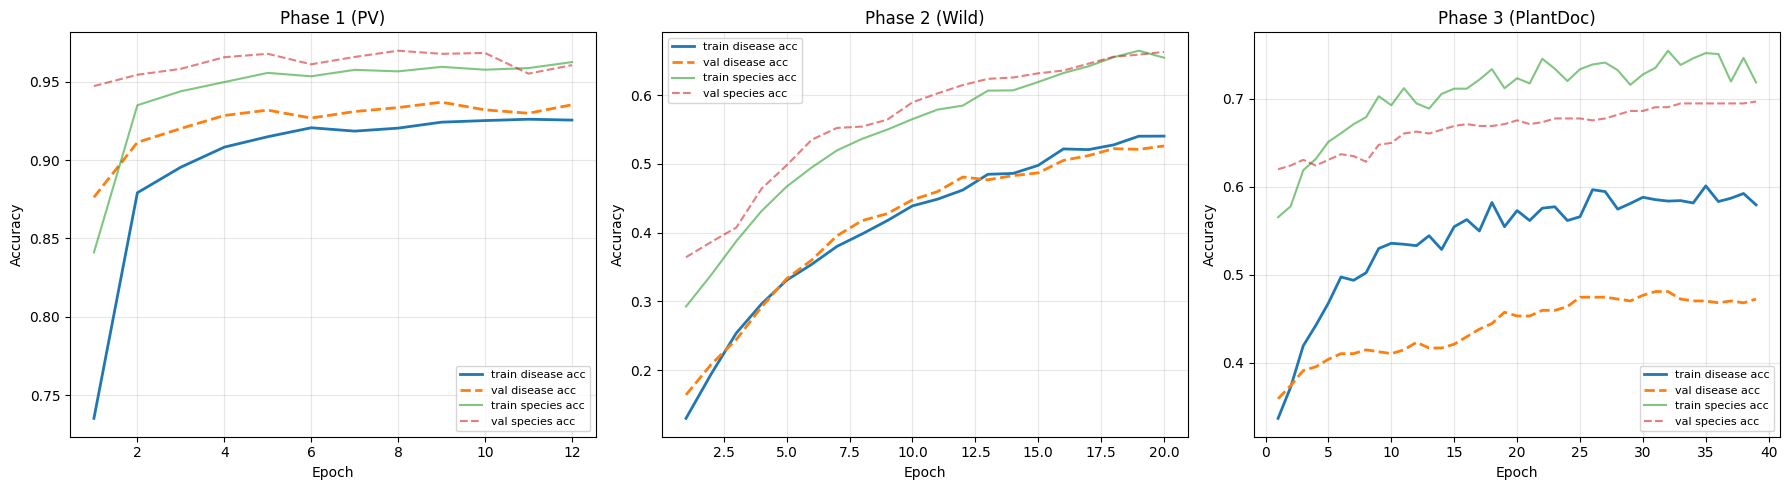

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
phase_labels = ['Phase 1 (PV)', 'Phase 2 (Wild)', 'Phase 3 (PlantDoc)']
histories = [h_p1, h_p2, h_p3]

for ax, h, title in zip(axes, histories, phase_labels):
    epochs = range(1, len(h.history['disease_accuracy']) + 1)
    ax.plot(epochs, h.history['disease_accuracy'],     label='train disease acc', lw=2)
    ax.plot(epochs, h.history['val_disease_accuracy'], label='val disease acc',   lw=2, linestyle='--')
    ax.plot(epochs, h.history['species_accuracy'],     label='train species acc', lw=1.5, alpha=0.6)
    ax.plot(epochs, h.history['val_species_accuracy'], label='val species acc',   lw=1.5, alpha=0.6, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPORT_DIR / 'two_head_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 17. Évaluation sur PlantDoc test

On évalue la **tête maladie** directement (sans cascade d'espèce).
On calcule aussi une version avec **masquage espèce optionnel** (contrainte soft).

In [20]:
def load_plantdoc_test_arrays():
    imgs, glob_labels = [], []
    for pd_cls, pv_cls in valid_pd_mapping.items():
        g = pv_label_to_idx.get(pv_cls)
        cls_dir = PLANTDOC_TEST_DIR / pd_cls
        if g is None or g not in allowed_set or not cls_dir.exists():
            continue
        for p in sorted(cls_dir.iterdir()):
            if not p.is_file():
                continue
            raw = tf.io.read_file(str(p))
            img = tf.image.decode_image(raw, channels=3, expand_animations=False)
            img.set_shape([None, None, 3])
            img = tf.image.resize(img, IMG_SIZE)
            imgs.append(tf.cast(img, tf.float32).numpy())
            glob_labels.append(g)
    return np.array(imgs), np.array(glob_labels)


X_test, y_test_glob = load_plantdoc_test_arrays()
y_test_pos     = np.array([global_to_pos[g] for g in y_test_glob])
y_test_species = np.array([int(pv_to_species_arr[g]) for g in y_test_glob])

print(f'PlantDoc test : {len(X_test)} images / {len(set(y_test_glob))} classes')

PlantDoc test : 236 images / 27 classes


In [ ]:
preds = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
disease_probs = preds['disease']   # shape (N, 27)
species_probs = preds['species']   # shape (N, 13)

disease_pred = np.argmax(disease_probs, axis=1)
species_pred = np.argmax(species_probs, axis=1)

# Top-1 / Top-3 (tête maladie directe) 
top1 = accuracy_score(y_test_pos, disease_pred)

top3_hits = 0
for i, true_pos in enumerate(y_test_pos):
    top3 = np.argsort(disease_probs[i])[-3:][::-1]
    if true_pos in top3:
        top3_hits += 1
top3 = top3_hits / len(y_test_pos)

f1_dis = f1_score(y_test_pos, disease_pred, average='macro', zero_division=0)
f1_sp  = f1_score(y_test_species, species_pred, average='macro', zero_division=0)

print(f'PlantDoc test — Tête maladie (directe)')
print(f'  Top-1 accuracy  : {top1*100:.2f} %')
print(f'  Top-3 accuracy  : {top3*100:.2f} %')
print(f'  Macro F1 (dis.) : {f1_dis*100:.2f} %')
print(f'  Macro F1 (esp.) : {f1_sp*100:.2f} %')

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
PlantDoc test — Tête maladie (directe)
  Top-1 accuracy  : 49.15 %
  Top-3 accuracy  : 74.58 %
  Macro F1 (dis.) : 48.23 %
  Macro F1 (esp.) : 65.28 %


In [ ]:
# Variante avec masquage espèce (contrainte soft) 
# Zero out les maladies qui n'appartiennent pas à l'espèce prédite.
# Utile seulement si la tête espèce est bien calibrée.

species_mask = np.zeros((n_species, n_allowed), dtype=np.float32)
for s in range(n_species):
    for g in species_disease_global[s]:
        species_mask[s, global_to_pos[g]] = 1.0

disease_probs_masked = disease_probs.copy()
for i, sp in enumerate(species_pred):
    disease_probs_masked[i] *= species_mask[sp]
    row_sum = disease_probs_masked[i].sum()
    if row_sum > 0:
        disease_probs_masked[i] /= row_sum

disease_pred_masked = np.argmax(disease_probs_masked, axis=1)
top1_masked = accuracy_score(y_test_pos, disease_pred_masked)
f1_masked   = f1_score(y_test_pos, disease_pred_masked, average='macro', zero_division=0)

print(f'PlantDoc test — Tête maladie avec masquage espèce')
print(f'  Top-1 accuracy  : {top1_masked*100:.2f} %')
print(f'  Macro F1        : {f1_masked*100:.2f} %')

PlantDoc test — Tête maladie avec masquage espèce
  Top-1 accuracy  : 50.85 %
  Macro F1        : 50.22 %


In [ ]:
# Rapport de classification détaillé 
label_names = [pos_to_name[p] for p in range(n_allowed)]

print('\nRapport de classification — tête maladie (directe) :')
print(classification_report(
    y_test_pos, disease_pred,
    target_names=label_names, zero_division=0))


Rapport de classification — tête maladie (directe) :
                                            precision    recall  f1-score   support

                        Apple___Apple_scab       1.00      0.40      0.57        10
                  Apple___Cedar_apple_rust       0.32      0.60      0.41        10
                           Apple___healthy       0.25      0.78      0.38         9
                       Blueberry___healthy       0.40      0.36      0.38        11
                          Cherry___healthy       0.31      0.40      0.35        10
Corn___Cercospora_leaf_spot Gray_leaf_spot       0.22      0.50      0.31         4
                        Corn___Common_rust       0.89      0.80      0.84        10
               Corn___Northern_Leaf_Blight       0.56      0.42      0.48        12
                         Grape___Black_rot       0.67      0.25      0.36         8
                           Grape___healthy       0.80      0.67      0.73        12
                     

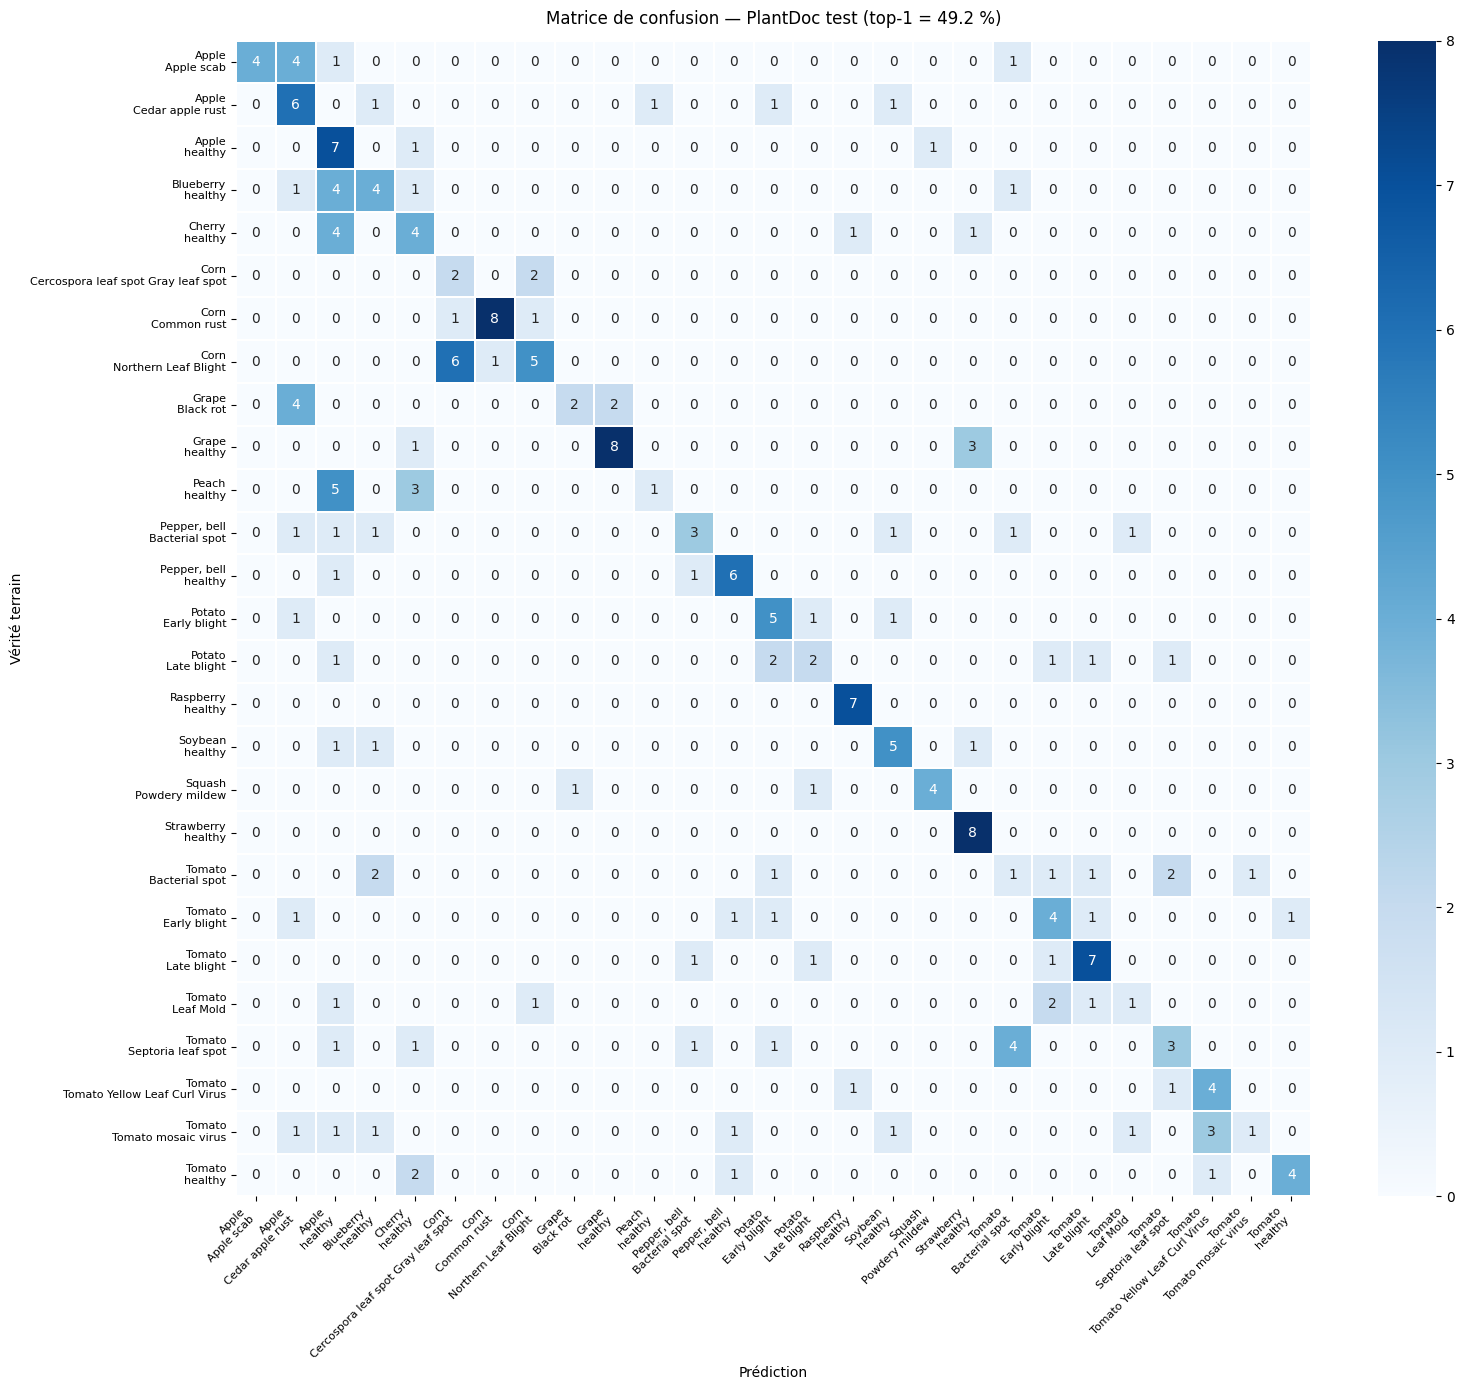

In [ ]:
# Matrice de confusion 
cm = confusion_matrix(y_test_pos, disease_pred)

short_names = [
    n.replace('___', '\n').replace('_', ' ')
    for n in label_names
]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=short_names, yticklabels=short_names,
    ax=ax, linewidths=0.3,
)
ax.set_title(f'Matrice de confusion — PlantDoc test (top-1 = {top1*100:.1f} %)', pad=12)
ax.set_xlabel('Prédiction')
ax.set_ylabel('Vérité terrain')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'two_head_confusion_plantdoc.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Évaluation sur PlantVillage test

Mesure la rétention des connaissances studio (robustesse à l'oubli catastrophique).

In [25]:
# Collecte des images et labels PV test en mémoire (même approche que PlantDoc)
pv_imgs, y_pv_pos_list, y_pv_sp_list = [], [], []
for img_tensor, lbl_tensor in pv_test_raw.filter(in_allowed):
    g = int(lbl_tensor.numpy())
    img_r = tf.cast(tf.image.resize(img_tensor, IMG_SIZE), tf.float32).numpy()
    pv_imgs.append(img_r)
    y_pv_pos_list.append(int(pv_to_pos_arr[g]))
    y_pv_sp_list.append(int(pv_to_species_arr[g]))

X_pv_test = np.array(pv_imgs)
y_pv_pos  = np.array(y_pv_pos_list)
y_pv_sp   = np.array(y_pv_sp_list)

preds_pv        = model.predict(X_pv_test, batch_size=BATCH_SIZE, verbose=1)
pv_disease_pred = np.argmax(preds_pv['disease'], axis=1)
pv_species_pred = np.argmax(preds_pv['species'], axis=1)

pv_top1 = accuracy_score(y_pv_pos, pv_disease_pred)
pv_top3_hits = sum(
    1 for i, t in enumerate(y_pv_pos)
    if t in np.argsort(preds_pv['disease'][i])[-3:][::-1]
)
pv_top3 = pv_top3_hits / len(y_pv_pos)
pv_f1   = f1_score(y_pv_pos, pv_disease_pred, average='macro', zero_division=0)

print(f'PlantVillage test ({n_allowed} classes, {len(X_pv_test)} images) :')
print(f'  Top-1 : {pv_top1*100:.2f} % | Top-3 : {pv_top3*100:.2f} % | Macro F1 : {pv_f1*100:.2f} %')

175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step
PlantVillage test (27 classes, 5569 images) :
  Top-1 : 82.89 % | Top-3 : 95.96 % | Macro F1 : 77.89 %


## 19. Résumé comparatif

Comparaison directe avec l'approche hiérarchique à deux étages.

In [26]:
print('=' * 65)
print('RÉSUMÉ COMPARATIF')
print('=' * 65)
print()
print('Approche hiérarchique (jalon4_plant_and_deseases) :')
print(f'  Étage 1 espèce  — PlantDoc top-1 : 69.92 %  | macro F1 : 63.37 %')
print(f'  End-to-end      — PlantDoc top-1 : 46.19 %  | macro F1 : 45.33 %')
print(f'  PlantVillage    — top-1          : 80.16 %')
print()
print('Modèle multi-têtes (ce notebook) :')
print(f'  Tête maladie    — PlantDoc top-1 : {top1*100:5.2f} %  | macro F1 : {f1_dis*100:.2f} %')
print(f'  + masquage esp. — PlantDoc top-1 : {top1_masked*100:5.2f} %  | macro F1 : {f1_masked*100:.2f} %')
print(f'  PlantVillage    — top-1          : {pv_top1*100:.2f} %')
print()
delta = (top1 - 0.4619) * 100
sign = '+' if delta >= 0 else ''
print(f'  → Delta PlantDoc top-1 vs hiérarchique : {sign}{delta:.1f} pts')
print('=' * 65)

RÉSUMÉ COMPARATIF

Approche hiérarchique (jalon4_plant_and_deseases) :
  Étage 1 espèce  — PlantDoc top-1 : 69.92 %  | macro F1 : 63.37 %
  End-to-end      — PlantDoc top-1 : 46.19 %  | macro F1 : 45.33 %
  PlantVillage    — top-1          : 80.16 %

Modèle multi-têtes (ce notebook) :
  Tête maladie    — PlantDoc top-1 : 49.15 %  | macro F1 : 48.23 %
  + masquage esp. — PlantDoc top-1 : 50.85 %  | macro F1 : 50.22 %
  PlantVillage    — top-1          : 82.89 %

  → Delta PlantDoc top-1 vs hiérarchique : +3.0 pts


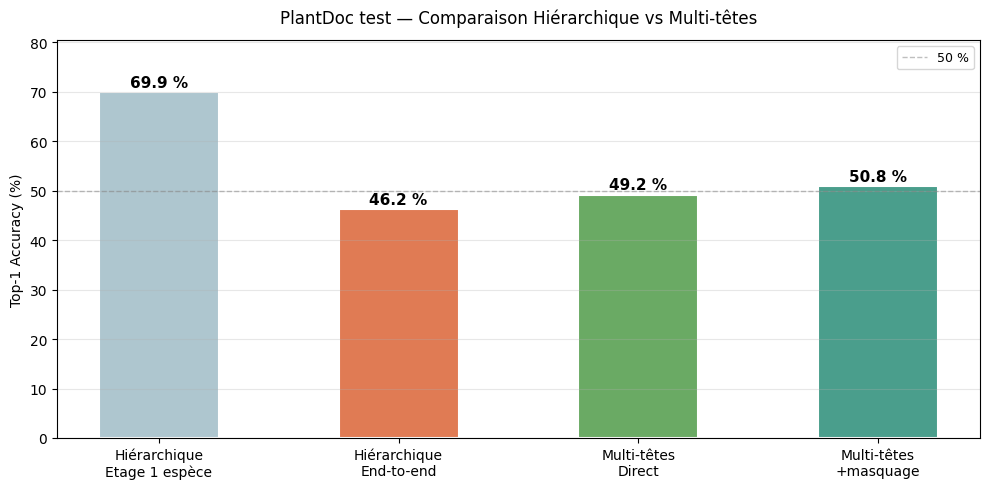

In [27]:
# ── Graphique comparatif ────────────────────────────────────────────────────
methods = ['Hiérarchique\nEtage 1 espèce', 'Hiérarchique\nEnd-to-end', 'Multi-têtes\nDirect', 'Multi-têtes\n+masquage']
top1_scores = [69.92, 46.19, top1 * 100, top1_masked * 100]
colors = ['#aec6cf', '#e07b54', '#6aaa64', '#4a9e8c']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(methods, top1_scores, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, top1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f} %', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50 %')
ax.set_ylim(0, max(top1_scores) * 1.15)
ax.set_ylabel('Top-1 Accuracy (%)')
ax.set_title('PlantDoc test — Comparaison Hiérarchique vs Multi-têtes', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'two_head_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 20. Sauvegarde des résultats

In [28]:
results = {
    'model': 'two_head_MobileNetV3Small',
    'plantdoc': {
        'top1_direct':  float(top1),
        'top3_direct':  float(top3),
        'macro_f1_disease': float(f1_dis),
        'macro_f1_species': float(f1_sp),
        'top1_masked':  float(top1_masked),
        'macro_f1_masked': float(f1_masked),
    },
    'plantvillage': {
        'top1': float(pv_top1),
        'top3': float(pv_top3),
        'macro_f1': float(pv_f1),
    },
    'baseline_hierarchical': {
        'plantdoc_stage1_top1': 0.6992,
        'plantdoc_e2e_top1': 0.4619,
        'plantdoc_e2e_macro_f1': 0.4533,
        'plantvillage_top1': 0.8016,
    },
}

out_path = REPORT_DIR / 'two_head_results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Résultats sauvegardés dans {out_path}')

Résultats sauvegardés dans /reports/two_head_results.json
